# Arbitrage Study – Data Ingestion & Cleaning (Paso 1)

Arrancamos construyendo las utilidades necesarias para:

1. Descubrir los libros disponibles en `DATA_SMALL` (Banco Santander en los cuatro venues).
2. Cargar los ficheros QTE/STSs por identidad `(session, isin, mic, ticker)`.
3. Limpiar las cotizaciones eliminando precios "mágicos" y snapshots sin horquillas válidas.
4. Filtrar los snapshots para quedarnos solo con los periodos de continuous trading definidos por el vendor.

Una vez completado, tendremos dataframes limpios y listos para los pasos siguientes (consolidated tape, señales y simulación de latencia).

In [1]:
# ---- Configuración global: imports, paths y constantes de limpieza ----
from pathlib import Path
from typing import Dict, Iterable, List, Tuple

import numpy as np
import pandas as pd

# Carpeta raíz (primero DATA_SMALL, luego apuntaremos a DATA_BIG)
#DATA_ROOT = Path("DATA_SMALL")
DATA_ROOT = Path("DATA_BIG")

# Valores especiales del vendor: indican estados no negociables -> reemplazamos por NaN
MAGIC_PRICE_VALUES = {
    666_666.666,
    999_999.999,
    999_999.989,
    999_999.988,
    999_999.979,
    999_999.123,
}

# Map MIC -> nombre de venue (nos ayuda a resolver rutas y códigos de estado)
MIC_TO_VENUE = {
    "XMAD": "BME",
    "CEUX": "CBOE",
    "AQEU": "AQUIS",
    "TQEX": "TURQUOISE",
}

# Estados de trading continuo por venue (solo estos snapshots son ejecutables)
CONTINUOUS_STATUS_CODES: Dict[str, set[int]] = {
    "AQUIS": {5_308_427},
    "BME": {5_832_713, 5_832_756},
    "CBOE": {12_255_233},
    "TURQUOISE": {7_608_181},
}

# Columnas de precios bid/ask nivel 0-9 utilizadas en los QTE
PRICE_COLUMNS = [
    f"px_{side}_{level}"
    for side in ("bid", "ask")
    for level in range(10)
]


In [2]:
# ---- Utilidades para descubrir libros y localizar ficheros QTE/STS ----
def strip_csv_gz_suffix(filename: str) -> str:
    """Elimina la extensión .csv.gz para poder trocear los nombres de archivo."""
    return filename[:-7] if filename.endswith(".csv.gz") else filename


def parse_order_book_from_filename(path: Path) -> Dict[str, str]:
    """Extrae metainformación (tipo, sesión, ISIN, ticker, MIC) a partir del nombre estándar."""
    base = strip_csv_gz_suffix(path.name)
    parts = base.split("_")
    if len(parts) < 6:
        raise ValueError(f"Unexpected file name format: {path.name}")

    file_type, session, isin, ticker, mic, part = parts[:6]
    return {
        "file_type": file_type,
        "session": session,
        "isin": isin,
        "ticker": ticker,
        "mic": mic,
        "part": part,
        "path": path,
    }


def discover_order_books(root: Path) -> pd.DataFrame:
    """Recorre DATA_ROOT y detecta todos los order books disponibles (según archivos QTE)."""
    rows = []
    for venue_dir in sorted(root.glob("*_*")):
        if not venue_dir.is_dir():
            continue
        for qte_path in venue_dir.glob("QTE_*.csv.gz"):
            meta = parse_order_book_from_filename(qte_path)
            if meta["file_type"] != "QTE":
                continue
            rows.append(
                {
                    "session": meta["session"],
                    "isin": meta["isin"],
                    "mic": meta["mic"],
                    "ticker": meta["ticker"],
                    "venue": MIC_TO_VENUE.get(meta["mic"], venue_dir.name.split("_")[0]),
                }
            )
    return pd.DataFrame(rows).drop_duplicates().reset_index(drop=True)


def build_book_id(session: str, isin: str, mic: str, ticker: str) -> Tuple[str, str, str, str]:
    """Convenience: empaqueta la identidad (session, isin, mic, ticker)."""
    return (session, isin, mic, ticker)


def resolve_book_folder(book_id: Tuple[str, str, str, str], root: Path = DATA_ROOT) -> Path:
    """Devuelve la carpeta venue_fecha para MIC conocidos o lanza error si no existe."""
    session, _, mic, _ = book_id
    venue = MIC_TO_VENUE.get(mic)
    if not venue:
        raise KeyError(f"MIC '{mic}' no reconocido en MIC_TO_VENUE. Usa resolve_book_path para fallback.")
    folder = root / f"{venue}_{session}"
    if not folder.exists():
        raise FileNotFoundError(f"Missing folder {folder}")
    return folder


def resolve_book_path(book_id: Tuple[str, str, str, str], file_type: str, root: Path = DATA_ROOT) -> Path:
    """Construye la ruta completa al archivo, con fallback automático si el MIC es nuevo."""
    session, isin, mic, ticker = book_id
    filename = f"{file_type}_{session}_{isin}_{ticker}_{mic}_1.csv.gz"

    candidate_folders = []
    try:
        candidate_folders.append(resolve_book_folder(book_id, root))
    except (KeyError, FileNotFoundError):
        pass

    # Fallback: cualquier carpeta *_session (ej. BME_2025-11-07) puede contener el archivo.
    candidate_folders.extend(path for path in root.glob(f"*_{session}") if path.is_dir())

    seen: set[str] = set()
    for folder in candidate_folders:
        folder_resolved = folder.resolve()
        folder_key = str(folder_resolved)
        if folder_key in seen:
            continue
        seen.add(folder_key)

        path = folder_resolved / filename
        if path.exists():
            return path

    raise FileNotFoundError(
        f"Expected file not found for book {book_id} (searched under {root}): {filename}"
    )


def load_qte(book_id: Tuple[str, str, str, str]) -> pd.DataFrame:
    """Lee el CSV comprimido de quotes en formato pandas."""
    path = resolve_book_path(book_id, "QTE")
    return pd.read_csv(path, sep=";", compression="gzip")


def load_sts(book_id: Tuple[str, str, str, str]) -> pd.DataFrame:
    """Lee el CSV comprimido de estados de mercado (STS)."""
    path = resolve_book_path(book_id, "STS")
    return pd.read_csv(path, sep=";", compression="gzip")


In [3]:
# ---- Limpieza de QTE y alineación con estados STS ----
def sanitize_price_levels(df: pd.DataFrame) -> pd.DataFrame:
    """Sustituye precios mágicos por NaN para evitar interpretarlos como cotizaciones reales."""
    df = df.copy()
    for col in PRICE_COLUMNS:
        if col in df.columns:
            df.loc[df[col].isin(MAGIC_PRICE_VALUES), col] = np.nan
    return df


def clean_qte(df: pd.DataFrame) -> pd.DataFrame:
    """Ordena por tiempo, limpia precios y descarta snapshots sin best bid/ask válido."""
    if "epoch" not in df.columns:
        raise KeyError("QTE dataframe missing 'epoch' column")
    df = sanitize_price_levels(df)
    df = df.sort_values("epoch").reset_index(drop=True)

    valid_book = (
        df["px_bid_0"].notna()
        & df["px_ask_0"].notna()
        & (df["px_bid_0"] > 0)
        & (df["px_ask_0"] > 0)
        & (df["px_ask_0"] >= df["px_bid_0"])
    )

    return df.loc[valid_book].copy()


def filter_sts_continuous(df: pd.DataFrame, venue: str) -> pd.DataFrame:
    """Retiene solo los registros STS cuyo código pertenece al modo continuous trading del venue."""
    if "market_trading_status" not in df.columns:
        raise KeyError("STS dataframe missing 'market_trading_status'")
    valid_codes = CONTINUOUS_STATUS_CODES[venue]
    df = df.sort_values("epoch").reset_index(drop=True)
    mask = df["market_trading_status"].isin(valid_codes)
    return df.loc[mask, ["epoch", "market_trading_status"]].copy()


def restrict_quotes_to_trading(qte_df: pd.DataFrame, sts_df: pd.DataFrame, venue: str) -> pd.DataFrame:
    """Aplica un merge_asof para eliminar snapshots fuera de continuous trading."""
    qte_df = qte_df.sort_values("epoch").copy()
    sts_cont = filter_sts_continuous(sts_df, venue)

    # Convertimos ambos a timestamps reales para poder usar tolerancias como Timedelta
    qte_df["ts"] = pd.to_datetime(qte_df["epoch"], unit="us")
    sts_cont["ts"] = pd.to_datetime(sts_cont["epoch"], unit="us")

    merged = pd.merge_asof(
        qte_df,
        sts_cont,
        on="ts",
        direction="backward",
        tolerance=pd.Timedelta("5s"),
    )

    # Si no existe un estado válido previo, descartamos el snapshot
    merged = merged.dropna(subset=["market_trading_status"])

    # Garantizamos que la columna 'epoch' exista (reconstruimos a partir de 'ts' si hace falta)
    if "epoch" not in merged.columns and "epoch_x" in merged.columns:
        merged = merged.rename(columns={"epoch_x": "epoch"})
    if "epoch" not in merged.columns:
        merged["epoch"] = (merged["ts"].view("int64") // 1_000).astype(np.int64)

    # Eliminamos columnas auxiliares y devolvemos el dataframe limpio
    cols_to_drop = [col for col in ("epoch_y", "ts", "market_trading_status") if col in merged.columns]
    merged = merged.drop(columns=cols_to_drop)

    return merged

In [5]:
# ---- Paso 2.1: Cargar y depurar las horquillas (best bid/ask + tamaños) de cada venue ----
books_available = discover_order_books(DATA_ROOT)
if books_available.empty:
    raise RuntimeError("No se encontraron QTE en DATA_SMALL; verifica la ruta de datos.")

clean_quote_frames: List[pd.DataFrame] = []

for _, row in books_available.iterrows():
    book_id = build_book_id(row["session"], row["isin"], row["mic"], row["ticker"])

    # 1) Leer y limpiar las cotizaciones del libro
    qte_raw = load_qte(book_id)
    qte_clean = clean_qte(qte_raw)

    # 2) Leer STS para filtrar periodos no operables
    sts_raw = load_sts(book_id)
    qte_active = restrict_quotes_to_trading(qte_clean, sts_raw, venue=row["venue"])

    # 3) Añadir timestamp legible y quedarnos con best bid/ask y tamaños
    venue_quotes = (
        qte_active.assign(ts=lambda df: pd.to_datetime(df["epoch"], unit="us"))
        .loc[:, ["ts", "px_bid_0", "px_ask_0", "qty_bid_0", "qty_ask_0"]]
        .rename(
            columns={
                "px_bid_0": "bid",
                "px_ask_0": "ask",
                "qty_bid_0": "bid_qty",
                "qty_ask_0": "ask_qty",
            }
        )
    )
    venue_quotes["mic"] = row["mic"]
    venue_quotes["venue"] = row["venue"]

    clean_quote_frames.append(venue_quotes)

# Confirmamos cuántos snapshots válidos tenemos por exchange
summary = (
    pd.concat(clean_quote_frames)
    .groupby(["venue", "mic"], as_index=False)
    .agg(num_snapshots=("ts", "count"))
)
display(summary)


,venue,mic,num_snapshots
0,AQUIS,AQEU,67
1,BME,GROW,45
2,BME,XLAT,2
3,BME,XMAD,8112
4,CBOE,CEUX,4005
5,TURQUOISE,TQEX,14


In [6]:
# ---- Paso 2.2: Construir la consolidated tape (índice temporal + bids/asks/tamaños por mic) ----
quotes_all = pd.concat(clean_quote_frames, ignore_index=True)
quotes_all.sort_values("ts", inplace=True)

# Algunos libros publican varias actualizaciones dentro del mismo microsegundo.
# Para poder pivotar sin duplicados, colapsamos cada (ts, mic) quedándonos con la última horquilla del instante.
quotes_dedup = (
    quotes_all.groupby(["ts", "mic"], as_index=False, sort=True)
    .last()
)

quotes_dedup.set_index("ts", inplace=True)

# Pivotamos para tener columnas bid/ask/bid_qty/ask_qty por mic
value_fields = ["bid", "ask", "bid_qty", "ask_qty"]
tape = quotes_dedup.pivot(columns="mic", values=value_fields)

# Forward-fill mantiene la última horquilla conocida hasta recibir una actualización
consolidated_tape = tape.ffill()

# Restructuramos las columnas para que sea más fácil de leer
consolidated_tape.columns = [f"{lvl0}_{lvl1}" for lvl0, lvl1 in consolidated_tape.columns]
consolidated_tape.head()

,bid_AQEU,bid_CEUX,bid_GROW,bid_TQEX,bid_XLAT,bid_XMAD,ask_AQEU,ask_CEUX,ask_GROW,ask_TQEX,...,bid_qty_GROW,bid_qty_TQEX,bid_qty_XLAT,bid_qty_XMAD,ask_qty_AQEU,ask_qty_CEUX,ask_qty_GROW,ask_qty_TQEX,ask_qty_XLAT,ask_qty_XMAD
ts,,,,,,,,,,,,,,,,,,,,,
2025-11-07 08:00:00.167790,31.5,NaN,NaN,NaN,NaN,NaN,46.7,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,72.0,NaN,NaN,NaN,NaN,NaN
2025-11-07 08:00:00.167883,31.5,NaN,NaN,NaN,NaN,NaN,46.7,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,170.0,NaN,NaN,NaN,NaN,NaN
2025-11-07 08:00:00.168620,31.5,NaN,NaN,NaN,NaN,NaN,46.7,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,170.0,NaN,NaN,NaN,NaN,NaN
2025-11-07 08:00:00.168627,31.5,NaN,NaN,NaN,NaN,NaN,46.7,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,170.0,NaN,NaN,NaN,NaN,NaN
2025-11-07 08:00:00.257013,31.5,NaN,NaN,NaN,NaN,NaN,46.7,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,162.0,NaN,NaN,NaN,NaN,NaN


In [7]:
# ---- Paso 3.1: NBBO, oportunidad y P&L teórico instantáneo ----
# Objetivo: detectar max bid vs min ask en la consolidated tape, cuantificar spread y P&L disponible sin latencia.

# 1) Identificamos columnas de bid/ask/size por MIC (mantuvimos tamaños en Paso 2.1)
bid_cols = sorted([col for col in consolidated_tape.columns if col.startswith("bid_") and not col.startswith("bid_qty_")])
ask_cols = sorted([col for col in consolidated_tape.columns if col.startswith("ask_") and not col.startswith("ask_qty_")])
bid_qty_cols = sorted([col for col in consolidated_tape.columns if col.startswith("bid_qty_")])
ask_qty_cols = sorted([col for col in consolidated_tape.columns if col.startswith("ask_qty_")])

# 2) Calculamos el NBBO y etiquetamos el MIC origen
nbbo = pd.DataFrame(index=consolidated_tape.index).copy()
nbbo["best_bid"] = consolidated_tape[bid_cols].max(axis=1, skipna=True)
nbbo["best_bid_mic"] = consolidated_tape[bid_cols].idxmax(axis=1)
nbbo["best_ask"] = consolidated_tape[ask_cols].min(axis=1, skipna=True)
nbbo["best_ask_mic"] = consolidated_tape[ask_cols].idxmin(axis=1)

# 3) Spread y flag binario de oportunidad (global max bid > global min ask)
nbbo["instant_spread_eur"] = nbbo["best_bid"] - nbbo["best_ask"]
nbbo["arb_flag"] = nbbo["instant_spread_eur"] > 0
nbbo["spread_bps"] = (nbbo["instant_spread_eur"] / nbbo["best_ask"]) * 1e4

# 4) Liquidez disponible en los lados implicados (lookup timestamp por timestamp)
def extract_qty(row: pd.Series, side: str) -> float:
    col = row[f"best_{side}_mic"]
    if pd.isna(col):
        return np.nan
    qty_col = col.replace(f"{side}_", f"{side}_qty_")
    return consolidated_tape.at[row.name, qty_col]

nbbo["best_bid_qty"] = nbbo.apply(lambda row: extract_qty(row, "bid"), axis=1)
nbbo["best_ask_qty"] = nbbo.apply(lambda row: extract_qty(row, "ask"), axis=1)
nbbo["tradable_qty"] = np.minimum(nbbo["best_bid_qty"], nbbo["best_ask_qty"])

# 5) P&L instantáneo (latencia 0) limitado por la liquidez cruzada
nbbo["instant_pnl_eur"] = nbbo["instant_spread_eur"] * nbbo["tradable_qty"]

# 6) Guardamos solo los timestamps con oportunidad y volumen ejecutable > 0
arb_windows = nbbo[nbbo["arb_flag"] & (nbbo["tradable_qty"] > 0)].copy()
display(nbbo.describe(include="all"))
display(arb_windows.head())

,best_bid,best_bid_mic,best_ask,best_ask_mic,instant_spread_eur,arb_flag,spread_bps,best_bid_qty,best_ask_qty,tradable_qty,instant_pnl_eur
count,10126.000000,10126,10126.000000,10126,10126.000000,10126,1.012600e+04,10126.000000,1.012600e+04,10126.000000,10126.000000
unique,NaN,4,NaN,6,NaN,2,NaN,NaN,NaN,NaN,NaN
top,NaN,bid_AQEU,NaN,ask_GROW,NaN,True,NaN,NaN,NaN,NaN,NaN
freq,NaN,7465,NaN,3621,NaN,10067,NaN,NaN,NaN,NaN,NaN
mean,64.432256,NaN,6.623650,NaN,57.808606,NaN,1.164590e+06,248.792811,3.681313e+04,83.862038,5053.278837
std,29.648074,NaN,8.867334,NaN,29.031864,NaN,3.321375e+06,2468.963992,3.444389e+05,151.662093,11589.270564
min,15.100000,NaN,0.008200,NaN,-15.620000,NaN,-3.314941e+03,1.000000,1.000000e+00,1.000000,-2584.000000
25%,54.820000,NaN,0.692000,NaN,50.362000,NaN,5.098565e+04,54.000000,7.410000e+02,54.000000,2474.820000
50%,54.820000,NaN,3.784000,NaN,53.720000,NaN,1.538864e+05,54.000000,1.698000e+03,54.000000,2826.360000
75%,55.100000,NaN,9.288000,NaN,54.670000,NaN,7.844928e+05,54.000000,5.000000e+03,54.000000,2952.180000


,best_bid,best_bid_mic,best_ask,best_ask_mic,instant_spread_eur,arb_flag,spread_bps,best_bid_qty,best_ask_qty,tradable_qty,instant_pnl_eur
ts,,,,,,,,,,,
2025-11-07 08:00:01.547402,54.72,bid_TQEX,18.31,ask_AQEU,36.41,True,19885.308575,343.0,16.0,16.0,582.56
2025-11-07 08:00:01.552022,54.72,bid_TQEX,18.00,ask_AQEU,36.72,True,20400.000000,343.0,50.0,50.0,1836.00
2025-11-07 08:00:01.553115,54.72,bid_TQEX,17.95,ask_AQEU,36.77,True,20484.679666,343.0,100.0,100.0,3677.00
2025-11-07 08:00:01.553557,54.72,bid_TQEX,17.95,ask_AQEU,36.77,True,20484.679666,343.0,100.0,100.0,3677.00
2025-11-07 08:00:01.565538,54.72,bid_TQEX,17.95,ask_AQEU,36.77,True,20484.679666,343.0,100.0,100.0,3677.00


In [8]:
# ---- Paso 3.2: Colapsar oportunidades persistentes (rising edges) y evitar doble conteo ----
# Regla: solo se puede ejecutar una vez cuando la señal pasa de OFF->ON. Mientras siga ON (hasta 1s o más) no se repite trade.

arb_mask = nbbo["arb_flag"].fillna(False) & (nbbo["tradable_qty"] > 0)
starts_mask = arb_mask & ~arb_mask.shift(fill_value=False)

# Enumeramos episodios sumando 1 en cada rising edge y anulando el resto
episode_ids = starts_mask.cumsum()
episode_ids = episode_ids.where(arb_mask, np.nan)

episodes = nbbo.loc[arb_mask].copy()
episodes["episode_id"] = episode_ids.loc[episodes.index].astype("Int64")

opportunity_rows = []
for eid, group in episodes.groupby("episode_id", dropna=True):
    first = group.iloc[0]
    start_ts = group.index[0]
    end_ts = group.index[-1]
    opportunity_rows.append(
        {
            "episode_id": int(eid),
            "start_ts": start_ts,
            "end_ts": end_ts,
            "duration_ms": (end_ts - start_ts).total_seconds() * 1_000,
            "num_snapshots": len(group),
            "best_bid_mic": first["best_bid_mic"],
            "best_ask_mic": first["best_ask_mic"],
            "spread_eur": first["instant_spread_eur"],
            "qty_eur": first["tradable_qty"],
            "pnl_eur": first["instant_pnl_eur"],
        }
    )

opportunities = pd.DataFrame(opportunity_rows)

total_pnl = opportunities["pnl_eur"].sum() if not opportunities.empty else 0.0
print(f"Oportunidades únicas detectadas: {len(opportunities)}")
print(f"P&L teórico (latencia 0, sin doble conteo): {total_pnl:,.2f} €")

display(opportunities.head())

Oportunidades únicas detectadas: 5
P&L teórico (latencia 0, sin doble conteo): 27,477.07 €


,episode_id,start_ts,end_ts,duration_ms,num_snapshots,best_bid_mic,best_ask_mic,spread_eur,qty_eur,pnl_eur
0,1,2025-11-07 08:00:01.547402,2025-11-07 08:00:01.565538,1.813600e+01,5,bid_TQEX,ask_AQEU,36.410,16.0,582.56
1,2,2025-11-07 08:00:01.684120,2025-11-07 08:00:01.684120,0.000000e+00,1,bid_TQEX,ask_AQEU,147.480,87.0,12830.76
2,3,2025-11-07 08:00:04.002171,2025-11-07 08:00:04.002171,0.000000e+00,1,bid_TQEX,ask_AQEU,147.480,87.0,12830.76
3,4,2025-11-07 08:00:04.127224,2025-11-07 08:00:04.128055,8.310000e-01,3,bid_AQEU,ask_TQEX,11.240,100.0,1124.00
4,5,2025-11-07 08:00:17.051939,2025-11-07 16:26:10.227405,3.035318e+07,10057,bid_AQEU,ask_CEUX,54.495,2.0,108.99


In [9]:
# ---- Paso 4: Simulación de latencia ("Time Machine") ----
# Regla: si detectamos la oportunidad en t0, solo podemos ejecutar en t0 + Δlatencia.
# Este bloque evalúa distintos retrasos y recalcula el P&L disponible en esos instantes diferidos.

LATENCY_GRID_US = [0, 100, 500, 1_000, 2_000, 3_000, 4_000, 5_000, 10_000, 15_000, 20_000, 30_000, 50_000, 100_000]
nbbo_sorted = nbbo.sort_index()
max_nbbo_ts = nbbo_sorted.index.max()

latency_summaries = []
latency_details = []

for latency_us in LATENCY_GRID_US:
    delay = pd.to_timedelta(latency_us, unit="us")
    eval_ts = pd.DatetimeIndex(opportunities["start_ts"] + delay, name="ts")

    # Obtenemos el estado del libro en t0 + Δ (ffill = asumimos que la última actualización sigue vigente)
    delayed_state = nbbo_sorted.reindex(eval_ts, method="ffill")

    # Si la latencia nos lleva más allá del final de la serie, marcamos esas filas como NaN (no tenemos datos)
    valid_mask = pd.Series(eval_ts <= max_nbbo_ts, index=eval_ts)
    delayed_state = delayed_state.where(valid_mask, np.nan)

    # Spread, liquidez y P&L realizables tras la latencia (solo si sigue habiendo oportunidad)
    realized_spread = delayed_state["instant_spread_eur"].clip(lower=0).fillna(0)
    realized_qty = delayed_state["tradable_qty"].where(delayed_state["instant_spread_eur"] > 0, 0).fillna(0)
    realized_pnl = realized_spread * realized_qty
    filled_mask = realized_pnl > 0

    latency_details.append(
        pd.DataFrame(
            {
                "episode_id": opportunities["episode_id"].values,
                "start_ts": opportunities["start_ts"].values,
                "latency_us": latency_us,
                "eval_ts": eval_ts.values,
                "realized_pnl_eur": realized_pnl.values,
                "filled": filled_mask.values,
            }
        )
    )

    latency_summaries.append(
        {
            "latency_us": latency_us,
            "tradeable_opportunities": int(filled_mask.sum()),
            "total_pnl_eur": float(realized_pnl.sum()),
            "avg_pnl_eur": float(realized_pnl[filled_mask].mean()) if filled_mask.any() else 0.0,
        }
    )

latency_curve = pd.DataFrame(latency_summaries).set_index("latency_us")
latency_details_df = pd.concat(latency_details, ignore_index=True)

print("\nLatencia -> P&L acumulado")
display(latency_curve)



Latencia -> P&L acumulado


,tradeable_opportunities,total_pnl_eur,avg_pnl_eur
latency_us,,,
0,5,27477.07,5495.414000
100,5,27477.07,5495.414000
500,4,14646.31,3661.577500
1000,4,14646.31,3661.577500
2000,4,14646.31,3661.577500
3000,4,14646.31,3661.577500
4000,4,14646.31,3661.577500
5000,4,15899.75,3974.937500
10000,4,17740.75,4435.187500


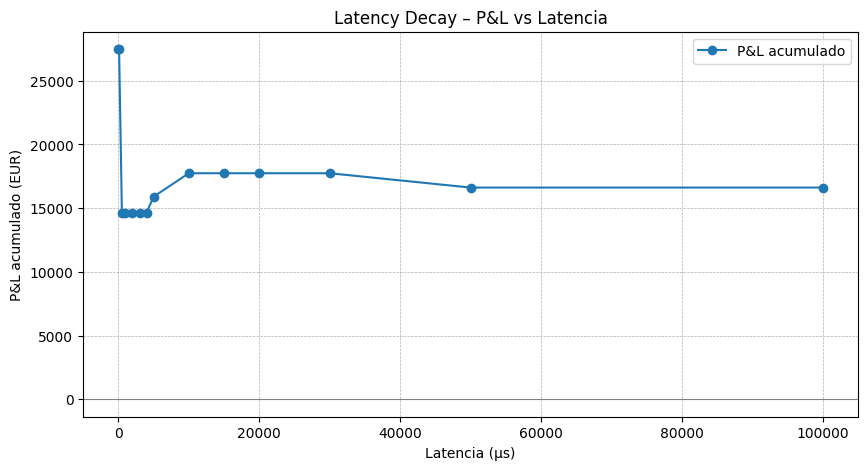

In [10]:
# ---- Visualización: Curva latencia vs P&L acumulado ----
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 5))
plt.plot(latency_curve.index, latency_curve["total_pnl_eur"], marker="o", label="P&L acumulado")
plt.axhline(0, color="grey", linewidth=0.8)
plt.title("Latency Decay – P&L vs Latencia")
plt.xlabel("Latencia (µs)")
plt.ylabel("P&L acumulado (EUR)")
plt.grid(True, which="both", linestyle="--", linewidth=0.5)
plt.legend()
plt.show()
